In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


In [2]:
df_test_f = pd.read_csv('test_final_processed.csv')
df_test_f

,sk_id_curr,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,...,ip_version_56.0_mean,ip_version_57.0_mean,ip_version_58.0_mean,ip_version_59.0_mean,ip_version_61.0_mean,ip_version_68.0_mean,ip_version_72.0_mean,ip_version_73.0_mean,ip_version_178.0_mean,ip_version_nan_mean
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_train_f = pd.read_csv('train_final_processed.csv')
df_train_f

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,ip_version_56.0_mean,ip_version_57.0_mean,ip_version_58.0_mean,ip_version_59.0_mean,ip_version_61.0_mean,ip_version_68.0_mean,ip_version_72.0_mean,ip_version_73.0_mean,ip_version_178.0_mean,ip_version_nan_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print(df_train_f.isnull().sum().sum())
print(df_test_f.isnull().sum().sum())


0
0


In [14]:
df_train_f['target'].value_counts()

target
0    282686
1     24825
Name: count, dtype: int64

In [27]:
print("Доля target=1 в df_train_f:", df_train_f['target'].mean())

Доля target=1 в df_train_f: 0.08072881945686496


Создание BaseModel

In [17]:
X = df_train_f.drop(columns=['sk_id_curr', 'target'])
y = df_train_f['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
categorical_columns = X_train.select_dtypes(include=['object']).columns
print(f"Категориальные колонки: {list(categorical_columns)}")

X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, prefix=categorical_columns, drop_first=True)

Категориальные колонки: ['name_contract_type', 'code_gender', 'flag_own_car', 'flag_own_realty', 'name_type_suite', 'name_income_type', 'name_education_type', 'name_family_status', 'name_housing_type', 'occupation_type', 'weekday_appr_process_start', 'organization_type', 'fondkapremont_mode', 'housetype_mode', 'wallsmaterial_mode', 'emergencystate_mode']


In [34]:
X_val_encoded = pd.get_dummies(X_val, columns=categorical_columns, prefix=categorical_columns, drop_first=True)

for col in X_train_encoded.columns:
    if col not in X_val_encoded.columns:
        X_val_encoded[col] = 0

X_val_encoded = X_val_encoded[X_train_encoded.columns]

In [31]:
base_model = GradientBoostingClassifier(
    n_estimators=100,           
    learning_rate=0.1,          
    max_depth=3,               
    random_state=42      
)
base_model.fit(X_train_encoded, y_train)

GradientBoostingClassifier(random_state=42)

In [36]:
y_val_pred_proba = base_model.predict_proba(X_val_encoded)[:, 1]
y_val_pred = (y_val_pred_proba >= 0.5).astype(int)

In [46]:
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred) 
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

ROC-AUC: 0.7684
Accuracy: 0.9201
Precision: 0.5855
Recall: 0.0228
F1-Score: 0.0440


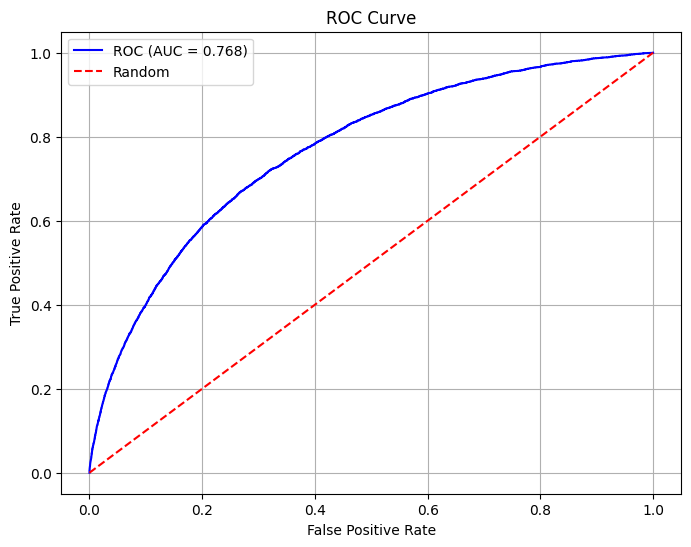

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

алгоритм XGBoost

In [42]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train_encoded, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
y_pred_xgb_proba = xgb_model.predict_proba(X_val_encoded)[:, 1]
y_pred_xgb = (y_pred_xgb_proba >= 0.5).astype(int)

In [45]:
xgb_auc = roc_auc_score(y_val, y_pred_xgb_proba)
xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
xgb_precision = precision_score(y_val, y_pred_xgb)
xgb_recall = recall_score(y_val, y_pred_xgb)
xgb_f1 = f1_score(y_val, y_pred_xgb)

print(f"ROC-AUC: {xgb_auc:.4f}")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1-Score: {xgb_f1:.4f}")

ROC-AUC: 0.7801
Accuracy: 0.9202
Precision: 0.5485
Recall: 0.0503
F1-Score: 0.0922


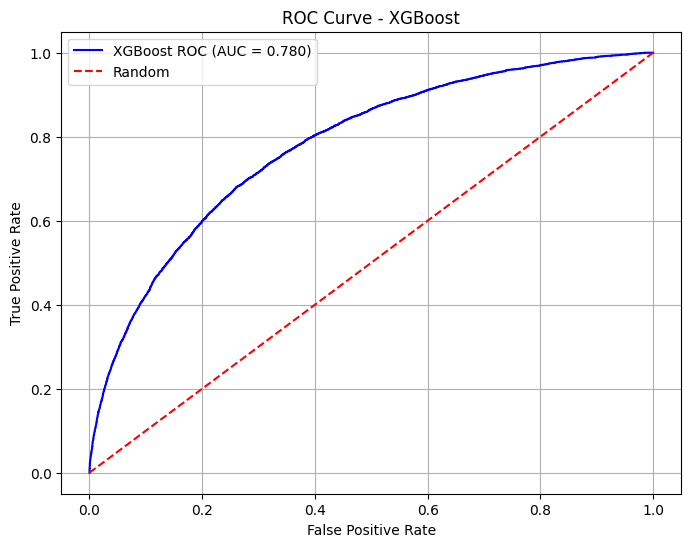

In [47]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_xgb_proba)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, 'b-', label=f'XGBoost ROC (AUC = {roc_auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()